In [7]:
import os
import cv2
from time import time
import numpy as np
from sklearn.utils import shuffle
from matplotlib import pyplot as plt
import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.layers import Dense, Input
from sklearn.preprocessing import LabelEncoder

plt.rcParams['figure.figsize'] = [15, 6]

Image 0 shape: (28, 28, 3)
Image 1 shape: (28, 28, 3)
Image 2 shape: (28, 28, 3)
Image 3 shape: (28, 28, 3)
Image 4 shape: (28, 28, 3)
Image 5 shape: (28, 28, 3)
Image 6 shape: (28, 28, 3)
Image 7 shape: (28, 28, 3)
Image 8 shape: (28, 28, 3)
Image 9 shape: (28, 28, 3)


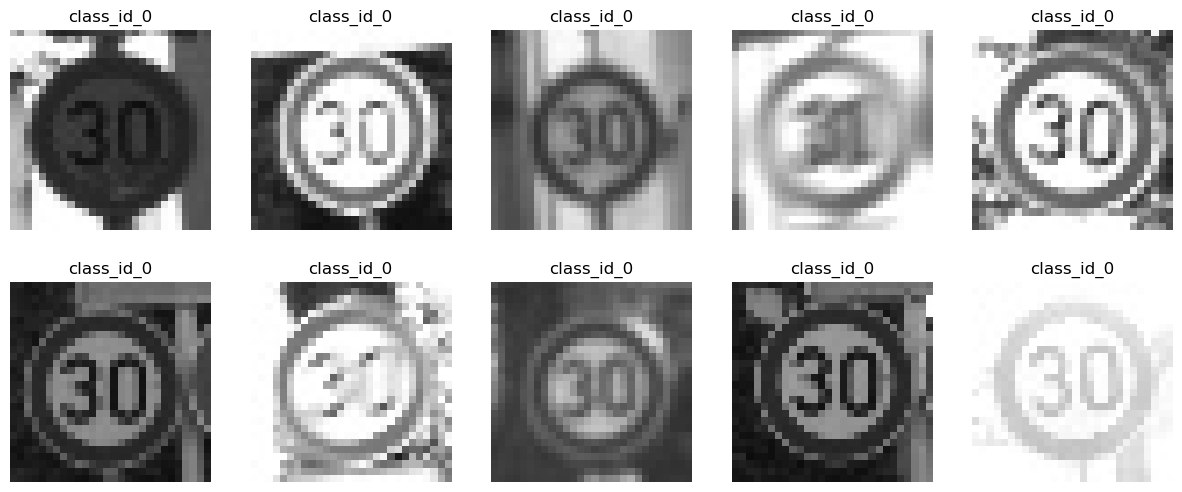

Image 0 shape: (28, 28, 3)
Image 1 shape: (28, 28, 3)
Image 2 shape: (28, 28, 3)
Image 3 shape: (28, 28, 3)
Image 4 shape: (28, 28, 3)
Image 5 shape: (28, 28, 3)
Image 6 shape: (28, 28, 3)
Image 7 shape: (28, 28, 3)
Image 8 shape: (28, 28, 3)
Image 9 shape: (28, 28, 3)


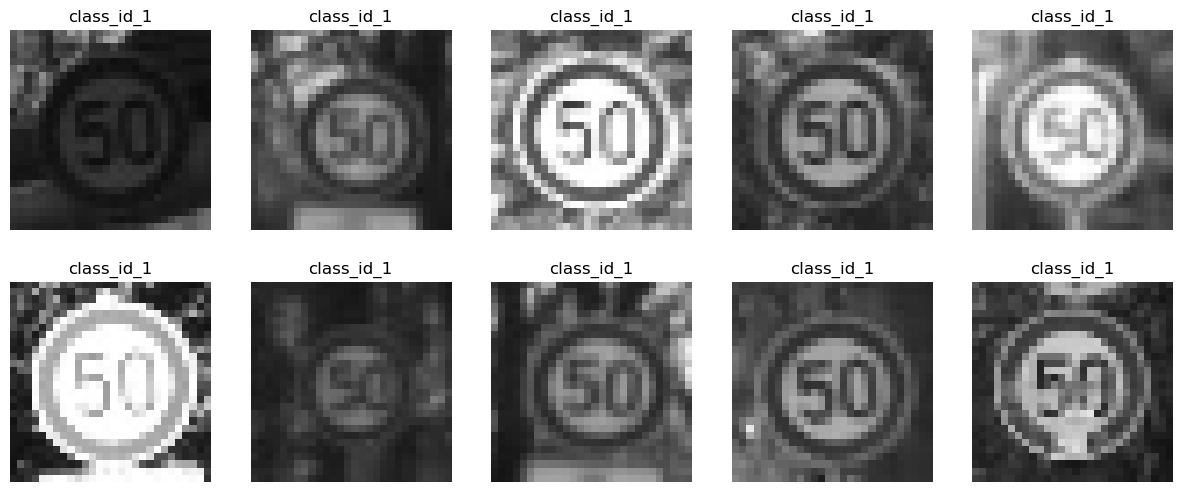

In [8]:
ClassData = (list[str], list[cv2.Mat], np.ndarray)

def load_image_class(class_name: str)-> ClassData:
    image_dir = os.path.join('data/subset_homework', class_name)
    image_files = [os.path.join(image_dir, f) for f in os.listdir(image_dir) if f.endswith('.jpg')]
    images = [cv2.imread(f) for f in image_files]
    labels = np.array([class_name] * len(images))
    return image_files, images, labels

def display_class_samples(class_data: ClassData):
    _, images, labels = class_data
    for i in range(min(10, len(images))):
        plt.subplot(2, 5, i + 1)
        plt.imshow(images[i], cmap='gray')
        plt.title(labels[i])
        plt.axis('off')
        print(f'Image {i} shape: {images[i].shape}')
    plt.show()

class_names = ['class_id_0', 'class_id_1']
class_data_list = [load_image_class(name) for name in class_names]
for class_data in class_data_list:
    display_class_samples(class_data)


In [12]:
images = np.concatenate([data[1] for data in class_data_list])
labels = np.concatenate([data[2] for data in class_data_list])
images, labels = shuffle(images, labels, random_state=42)
flatten_images = np.array([image.flatten() for image in images]) / 255
print(f'Total images: {len(images)}/{len(labels)}')
print(flatten_images.shape, flatten_images[0].shape, flatten_images[0].dtype)
print(f"Labels sample: {labels.shape}, {labels[:10]}")

encoder = LabelEncoder()
encoded_labels = encoder.fit_transform(labels)
print(f"Encoded labels sample: {encoded_labels.shape}, {encoded_labels[:10]}")


Total images: 4470/4470
(4470, 2352) (2352,) float64
Labels sample: (4470,), ['class_id_1' 'class_id_1' 'class_id_0' 'class_id_0' 'class_id_0'
 'class_id_1' 'class_id_1' 'class_id_0' 'class_id_1' 'class_id_1']
Encoded labels sample: (4470,), [1 1 0 0 0 1 1 0 1 1]


In [13]:
inputs = Input(shape=(flatten_images.shape[1],))
outputs = Dense(1, activation="linear")(inputs)
model = Model(inputs, outputs)

model.summary()
tf.keras.utils.plot_model(model, to_file="model.png", show_shapes=True, show_layer_names=True)

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 2352)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │         2,353 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,353 (9.19 KB)

 Trainable params: 2,353 (9.19 KB)

 Non-trainable params: 0 (0.00 B)

You must install pydot (`pip install pydot`) for `plot_model` to work.


In [14]:
model.compile(optimizer ='adam', loss = 'mean_squared_error')
history = model.fit(flatten_images, encoded_labels, epochs=10, batch_size=32)

Epoch 1/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 615us/step - loss: 0.2879
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 615us/step - loss: 0.2879
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 566us/step - loss: 0.1843
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 566us/step - loss: 0.1843
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 568us/step - loss: 0.1469
Epoch 4/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 568us/step - loss: 0.1469
Epoch 4/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 560us/step - loss: 0.1310
Epoch 5/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 560us/step - loss: 0.1310
Epoch 5/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 549us/step - loss: 0.1179
Epoch 6/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 549us/step - loss: 0.1179
Epoch 6/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 552us/step - loss: 0.1200
Epoch 7/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 552us/step - loss: 0.1200
Epoch 7/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 546us/step - loss: 0.1098
Epoch 8/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 546us/step - loss: 0.1098
Epoch 8/10
140/140 ━━━━━━━━━━━━━━━

(Text(0.5, 0, 'epoch'), Text(0, 0.5, 'loss'))

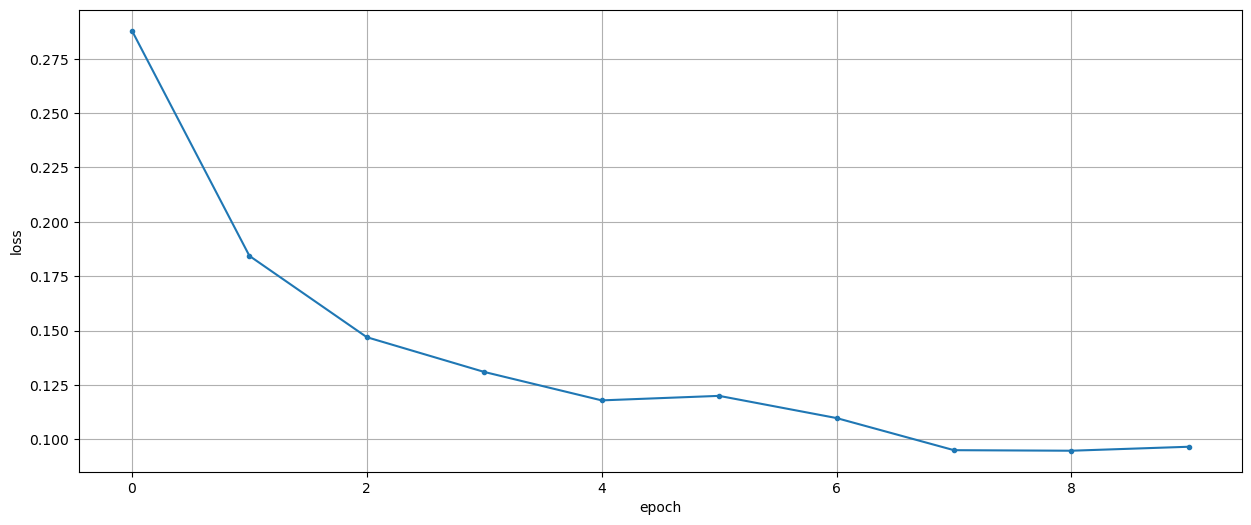

In [15]:
h = history.history
epochs = range(len(h['loss']))
plt.plot(epochs, h['loss'], '.-'), plt.grid(True)
plt.xlabel('epoch'), plt.ylabel('loss')

[0.3535094] [0.3535094]


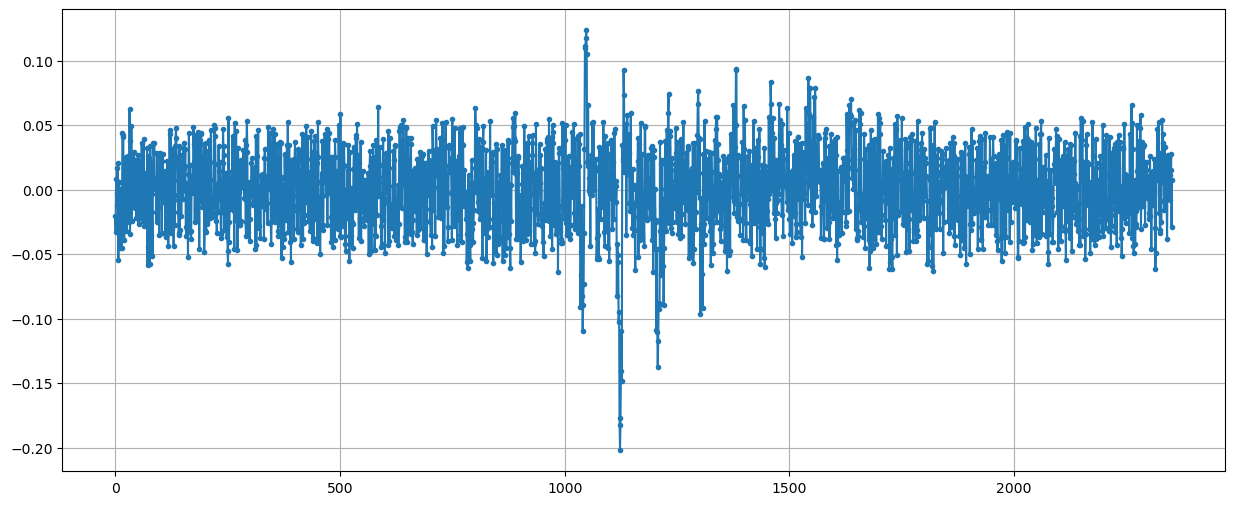

In [16]:
plt.plot(model.layers[1].weights[0].numpy(), '.-'), plt.grid(True)
print(model.layers[1].weights[1].numpy(), model.layers[1].bias.numpy())

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
[[0.11245675]] class_id_0
  1/140 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step[[0.11245675]] class_id_0
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 402us/step
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 402us/step
Accuracy 0.0
Accuracy 0.0


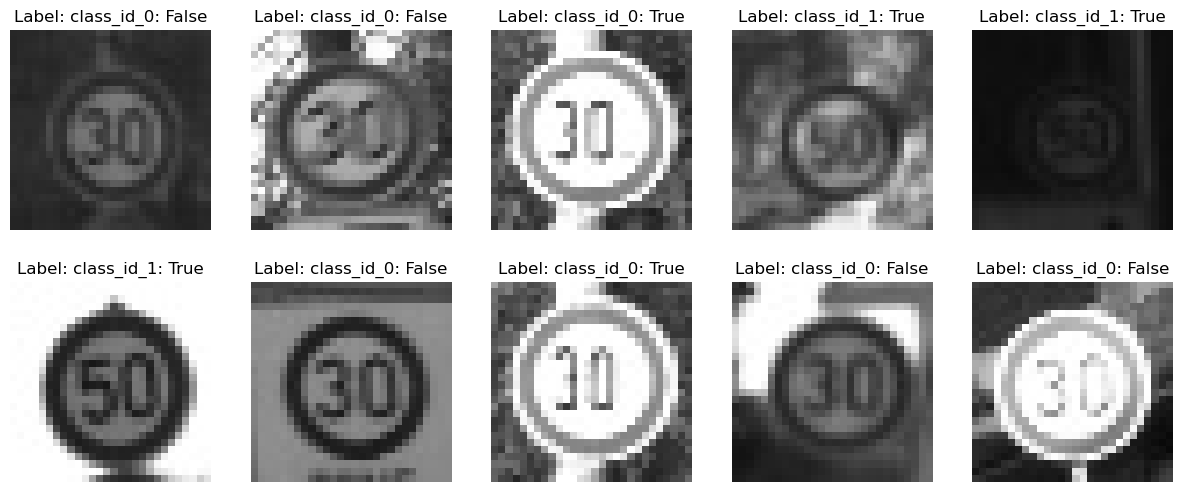

In [19]:
idx = 50
pred = model.predict(flatten_images[idx:idx+1, ...])
print(pred, labels[idx])
predictions = model.predict(flatten_images).squeeze()
predictions = predictions > 0.5
correct = 0
for prediction, label in zip(predictions, labels):
    if prediction == label:
        correct = correct + 1

print('Accuracy', correct/len(labels))
for cnt, idx in enumerate(np.random.randint(0, len(images), 10)):
    plt.subplot(2,5,cnt+1), plt.imshow(images[idx], cmap='gray', vmin=0, vmax=255)
    plt.title(f"Label: {labels[idx]}: {predictions[idx]}")
    plt.axis(False)